# Project 1 - Milestone 3: YOLOv8 Transfer Learning and Evaluation
**IE7615 - Group 02**

This notebook fine-tunes pretrained YOLOv8 models to detect and name 13 celebrities in synthetic 3x3 face
grids built with the Milestone 2 method, then produces every Milestone 3 deliverable:

| Step | Rubric item | Output |
|---|---|---|
| 1-2 | Scaled dataset (Milestone 2 method) + reference run on the original Milestone 2 data | `detection_dataset_m3/`, `results/milestone3/m2_original_reference.json` |
| 3 | YOLOv8 training + hyperparameter sweep (lr, image size, augmentation) | `results/milestone3/training_sweep.csv`, `train_logs/` |
| 4 | Final model + test metrics (mAP@0.5, mAP@0.5:0.95, IoU, precision, recall, per identity) | `models/celeba_yolov8_best.pt`, `results/milestone3/test_metrics*.{json,csv}`, `loss_curves.png` |
| 5 | Inference-threshold sweep (confidence, NMS IoU) | `results/milestone3/threshold_sweep*` |
| 6 | Detection gallery (successes + failures, captioned) | `results/milestone3/gallery/` |
| 7 | Live demo | `src/demo_detect.py` |
| 8 | Results document | `docs/milestone3_detection_results.md` |

**How to run (Google Colab):** *Runtime -> Change runtime type -> T4 GPU*, then *Runtime -> Run all*.
Everything takes roughly 45-60 minutes on a T4. The same pipeline runs from the command line with
`python src/run_milestone3.py`; the logic lives in `src/m3_detection.py` and `src/run_milestone3.py`.

In [1]:
# 0. Setup: find (or clone) the repo, install dependencies
import os, subprocess, sys
from pathlib import Path

REPO_URL = "https://github.com/AHonGa/ie7615-group-02-project1.git"
IN_COLAB = "google.colab" in sys.modules

here = Path.cwd().resolve()
ROOT = next((p for p in [here, *here.parents] if (p / "src" / "m3_detection.py").is_file()), None)
if ROOT is None:  # e.g. a fresh Colab runtime
    if not Path("ie7615-group-02-project1").exists():
        subprocess.run(["git", "clone", "-q", REPO_URL], check=True)
    ROOT = Path("ie7615-group-02-project1").resolve()
    # Milestone 3 code not pushed yet? Add it from milestone3_code.zip instead.
    if not (ROOT / "src" / "m3_detection.py").is_file():
        import zipfile
        # any upload named milestone3_code*.zip, e.g. "milestone3_code (2).zip"; newest wins
        zips = sorted(Path(".").glob("milestone3_code*.zip"), key=lambda p: p.stat().st_mtime)
        code_zip = zips[-1] if zips else Path("milestone3_code.zip")
        if not code_zip.is_file() and IN_COLAB:
            from google.colab import files
            print("Milestone 3 code is not on GitHub yet - choose milestone3_code.zip to upload:")
            code_zip = Path(next(iter(files.upload())))
        zipfile.ZipFile(code_zip).extractall(ROOT)
        print(f"Added the Milestone 3 code from {code_zip.name}")
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / "src"))

subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ultralytics", "gradio"], check=True)
print("Repo root:", ROOT)

Added the Milestone 3 code from milestone3_code_v2.zip
Repo root: /content/ie7615-group-02-project1


In [2]:
import torch, ultralytics
import pandas as pd
from IPython.display import Image, Markdown, display

import m3_detection as m3
import run_milestone3 as pipeline

HAS_GPU = torch.cuda.is_available()
DEVICE = 0 if HAS_GPU else "cpu"
EPOCHS = 100 if HAS_GPU else 10   # CPU fallback only for a quick functional check
PATIENCE = 30
BATCH = 16
print(f"ultralytics {ultralytics.__version__} | torch {torch.__version__} | "
      f"device: {torch.cuda.get_device_name(0) if HAS_GPU else 'CPU'}")
if not HAS_GPU:
    print("WARNING: no GPU. Switch the Colab runtime to a T4 GPU for the real results; "
          "EPOCHS is reduced to 10 so the notebook still runs end to end.")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
ultralytics 8.4.173 | torch 2.11.0+cu130 | device: Tesla T4


## 1. Dataset

The submitted Milestone 2 dataset (`detection_dataset/`, 6 base grids / 30 images) shows each celebrity in
only about 4 of its ~25 face photos, and its val/test splits are single grids that miss 4 identities each.
A first training run on it learned box locations but not identities: validation classification loss
stayed high because the model memorized those few photos.

`src/build_m3_scaled_dataset.py` rebuilds the dataset with the **same Milestone 2 method** (same 13
identities and class ids, 640 px 3x3 grids, same scale/placement jitter and backgrounds) and changes only:

- **photo-level split first**: each identity's photos are split 70/15/15 into train/val/test before any
  grid is built, so no photo appears in two splits;
- **more grids, all photos used**: 120 train / 12 val / 12 test grids that cycle through every photo;
- **balanced identities**: every identity, including Group 02's 3/7/1212/8335, appears in every split.

The build is deterministic (seed 42). Each identity is one YOLO class named `celeb_<CelebA identity id>`.

# YOLOv8 dataset config for the synthetic multi-celebrity detection dataset.
# Split folders are resolved relative to this file. Generated by src/m3_detection.py.
train: train/images
val: val/images
test: test/images
nc: 13
names:
  0: celeb_3
  1: celeb_7
  2: celeb_797
  3: celeb_1212
  4: celeb_2336
  5: celeb_2619
  6: celeb_2970
  7: celeb_4422
  8: celeb_4428
  9: celeb_5695
  10: celeb_7007
  11: celeb_8335
  12: celeb_10002

Scaled dataset (used for the sweep and final model):


,split,images,faces,identities_present,identities_missing
0,train,120,1080,13,-
1,val,12,108,13,-
2,test,12,108,13,-


Original Milestone 2 dataset (reference run):


,split,images,faces,identities_present,identities_missing
0,train,20,180,13,-
1,val,5,45,9,"celeb_4428, celeb_5695, celeb_7007, celeb_10002"
2,test,5,45,9,"celeb_3, celeb_1212, celeb_7007, celeb_8335"


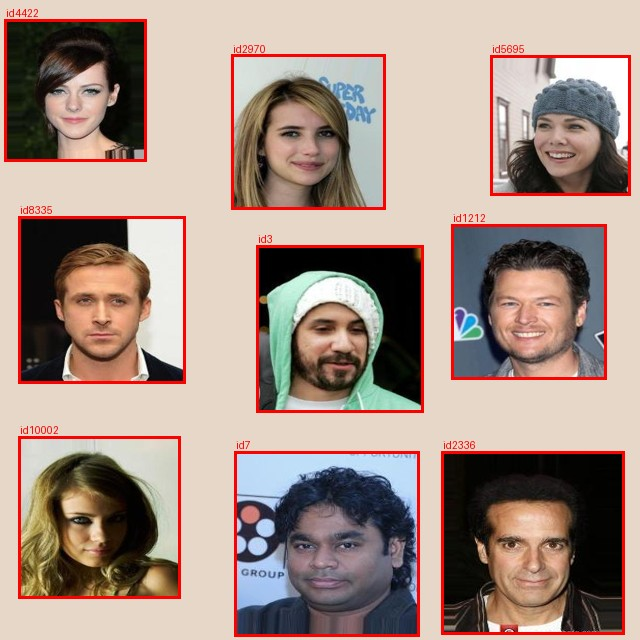

In [3]:
DATA_YAML = pipeline.step_build_dataset()
print(DATA_YAML.read_text())
print("Scaled dataset (used for the sweep and final model):")
display(m3.split_summary(m3.SCALED_DATASET_DIR))
print("Original Milestone 2 dataset (reference run):")
display(m3.split_summary(m3.M2_DATASET_DIR))
display(Image(str(m3.SCALED_DATASET_DIR / "previews" / "train_0001_preview.jpg"), width=420))

### Reference run on the original Milestone 2 dataset

The baseline configuration is first trained and tested on the submitted Milestone 2 data, so the
results document can show what the scaled dataset changes. Each dataset is scored on its own test split.

In [4]:
m2_ref = pipeline.step_m2_reference(EPOCHS, PATIENCE, BATCH, device=DEVICE)
display(pd.DataFrame([m2_ref]).round(3))


=== Training baseline on the original Milestone 2 dataset (reference) ===
Ultralytics 8.4.173 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/ie7615-group-02-project1/detection_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, m

,dataset,epochs_run,val mAP50,val mAP50-95,test mAP50,test mAP50-95,test precision,test recall,test mean IoU,faces correct
0,Milestone 2 original (20/5/5 images),70,0.341,0.232,0.232,0.15,0.452,0.4,0.873,3/45


## 2. Training and the training-time hyperparameter sweep

All runs start from COCO-pretrained `yolov8n.pt` (transfer learning) with AdamW, seed 42 and early
stopping (patience 30). The optimizer is fixed to AdamW because Ultralytics' default `optimizer="auto"`
ignores `lr0`, which would make a learning-rate sweep meaningless. Six configurations vary learning rate,
image size, augmentation intensity and model size (YOLOv8n vs the larger YOLOv8s), one at a time:

In [5]:
display(pd.DataFrame([c.as_row() for c in m3.SWEEP_CONFIGS]))

,run,model,lr0,imgsz,augmentation,what changes
0,baseline,yolov8n,0.0010,640,Ultralytics defaults,"Reference: AdamW lr0=0.001, 640 px, default on..."
1,lr_low,yolov8n,0.0002,640,Ultralytics defaults,Learning rate 5x lower
2,lr_high,yolov8n,0.0050,640,Ultralytics defaults,Learning rate 5x higher
3,imgsz_416,yolov8n,0.0010,416,Ultralytics defaults,"Smaller input resolution (faster, smaller faces)"
4,aug_light,yolov8n,0.0010,640,"mosaic=0.0, scale=0.2, translate=0.05, hsv_h=0...","Lighter online augmentation (no mosaic, gentle..."
5,yolov8s_aug_light,yolov8s,0.0010,640,"mosaic=0.0, scale=0.2, translate=0.05, hsv_h=0...","Larger model (YOLOv8s, ~3x parameters) with li..."


In [6]:
# Trains all 6 runs (finished runs are reused if you re-run this cell after an interruption).
run_dirs = pipeline.step_train_sweep(DATA_YAML, EPOCHS, PATIENCE, BATCH, device=DEVICE)


=== Training baseline: Reference: AdamW lr0=0.001, 640 px, default online augmentation ===
Ultralytics 8.4.173 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/ie7615-group-02-project1/detection_dataset_m3/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train,

Each run's best checkpoint is scored on **validation** (used to pick the final model) and on **test**
(reported only). Selecting on validation keeps the test split an honest held-out estimate.

Ultralytics 8.4.173 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,008,183 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2848.9±723.9 MB/s, size: 104.9 KB)
val: Scanning /content/ie7615-group-02-project1/detection_dataset_m3/val/labels.cache... 12 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 12/12 3.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 3.6it/s 0.3s
                   all         12        108      0.846      0.815      0.897      0.896
Speed: 0.4ms preprocess, 8.6ms inference, 0.0ms loss, 3.1ms postprocess per image
Results saved to /content/ie7615-group-02-project1/runs/milestone3/baseline_val
Ultralytics 8.4.173 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,008,183 parameters, 0 gradients, 8.1 GFLOPs
WARNING ⚠️ val: Slow image access detected (pin

,run,model,lr0,imgsz,augmentation,what changes,epochs_run,val mAP50,val mAP50-95,test mAP50,test mAP50-95,test precision,test recall
0,baseline,yolov8n,0.001,640,Ultralytics defaults,"Reference: AdamW lr0=0.001, 640 px, default on...",62,0.897,0.896,0.799,0.789,0.648,0.824
1,lr_low,yolov8n,0.000,640,Ultralytics defaults,Learning rate 5x lower,81,0.864,0.863,0.861,0.855,0.785,0.810
2,lr_high,yolov8n,0.005,640,Ultralytics defaults,Learning rate 5x higher,100,0.737,0.737,0.687,0.682,0.471,0.722
3,imgsz_416,yolov8n,0.001,416,Ultralytics defaults,"Smaller input resolution (faster, smaller faces)",100,0.835,0.835,0.847,0.842,0.741,0.787
4,aug_light,yolov8n,0.001,640,"mosaic=0.0, scale=0.2, translate=0.05, hsv_h=0...","Lighter online augmentation (no mosaic, gentle...",100,0.947,0.947,0.879,0.876,0.849,0.759
5,yolov8s_aug_light,yolov8s,0.001,640,"mosaic=0.0, scale=0.2, translate=0.05, hsv_h=0...","Larger model (YOLOv8s, ~3x parameters) with li...",100,0.933,0.933,0.936,0.932,0.833,0.891


Selected on validation mAP@0.5:0.95: aug_light


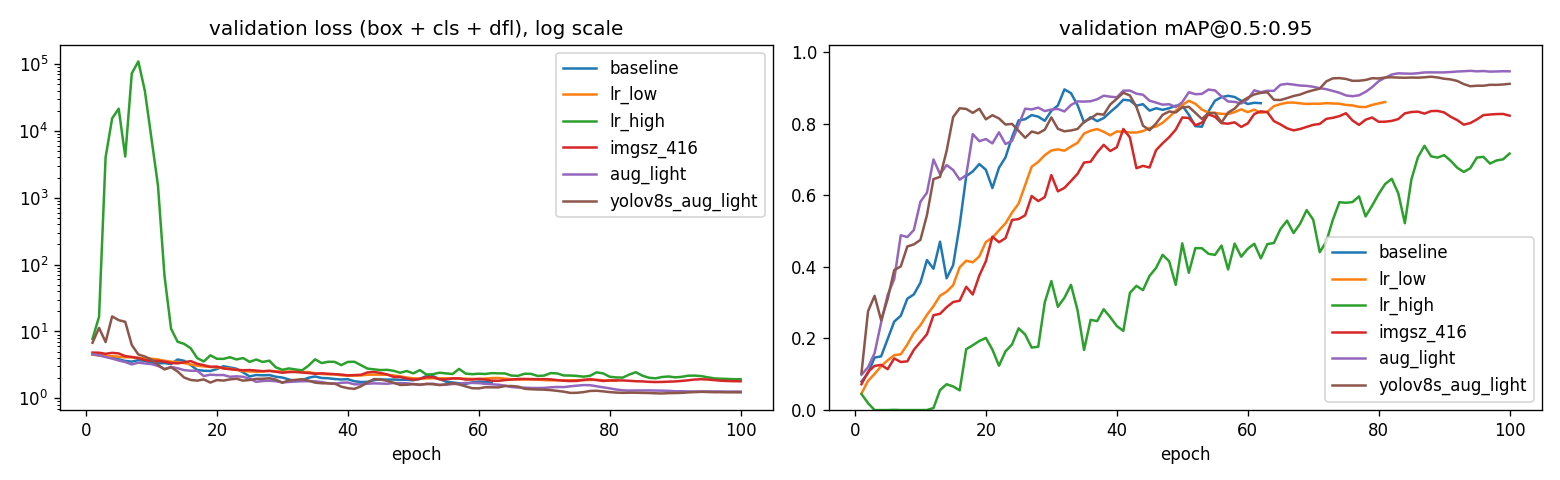

In [7]:
sweep_df, BEST_RUN = pipeline.step_compare_runs(run_dirs, DATA_YAML)
display(sweep_df.round(3))
print("Selected on validation mAP@0.5:0.95:", BEST_RUN)
display(Image(str(m3.RESULTS_DIR / "training_sweep_curves.png")))

## 3. Final model: test-set metrics and loss curves

The selected checkpoint is copied to `models/celeba_yolov8_best.pt`. mAP@0.5, mAP@0.5:0.95, precision
and recall come from Ultralytics' validator on the test split. **IoU** is not reported by Ultralytics, so
`m3.predict_and_match` matches each prediction to the ground-truth face it overlaps most (IoU >= 0.5,
confidence 0.25, NMS IoU 0.7) and averages IoU over correctly identified faces.

In [8]:
report = pipeline.step_final_model(run_dirs, BEST_RUN, DATA_YAML)
IMGSZ = report["config"]["imgsz"]
display(pd.DataFrame([{**report["test_overall"], "mean IoU": report["test_operating_point"]["mean_iou"]}]).round(3))
op = report["test_operating_point"]
print(f"Faces: {op['faces']} | correct identity: {op['correct']} | wrong identity: {op['wrong_identity']} | "
      f"missed: {op['missed']} | false positives: {op['false_positive']}")
display(pd.read_csv(m3.RESULTS_DIR / "test_metrics_per_class.csv").round(3))

Ultralytics 8.4.173 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,008,183 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3017.2±576.8 MB/s, size: 106.7 KB)
val: Scanning /content/ie7615-group-02-project1/detection_dataset_m3/test/labels.cache... 12 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 12/12 3.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 3.7it/s 0.3s
                   all         12        108      0.849      0.759      0.879      0.876
Speed: 0.4ms preprocess, 7.3ms inference, 0.0ms loss, 3.4ms postprocess per image
Results saved to /content/ie7615-group-02-project1/runs/milestone3/final_test


,precision,recall,mAP50,mAP50-95,mean IoU
0,0.849,0.759,0.879,0.876,0.993


Faces: 108 | correct identity: 84 | wrong identity: 24 | missed: 0 | false positives: 8


,class,identity,test faces,precision,recall,mAP50,mAP50-95,mean IoU
0,0,celeb_3 (ours),8,1.000,0.543,0.995,0.995,0.994
1,1,celeb_7 (ours),8,0.991,1.000,0.995,0.995,0.994
2,2,celeb_797,8,0.968,0.750,0.927,0.927,0.992
3,3,celeb_1212 (ours),9,0.892,1.000,0.995,0.995,0.994
4,4,celeb_2336,8,1.000,0.933,0.995,0.995,0.994
5,5,celeb_2619,9,0.925,0.444,0.802,0.787,0.991
6,6,celeb_2970,8,0.704,0.750,0.792,0.792,0.990
7,7,celeb_4422,9,0.631,0.556,0.788,0.788,0.989
8,8,celeb_4428,8,0.727,0.375,0.641,0.638,0.994
9,9,celeb_5695,8,0.817,0.625,0.683,0.666,0.993


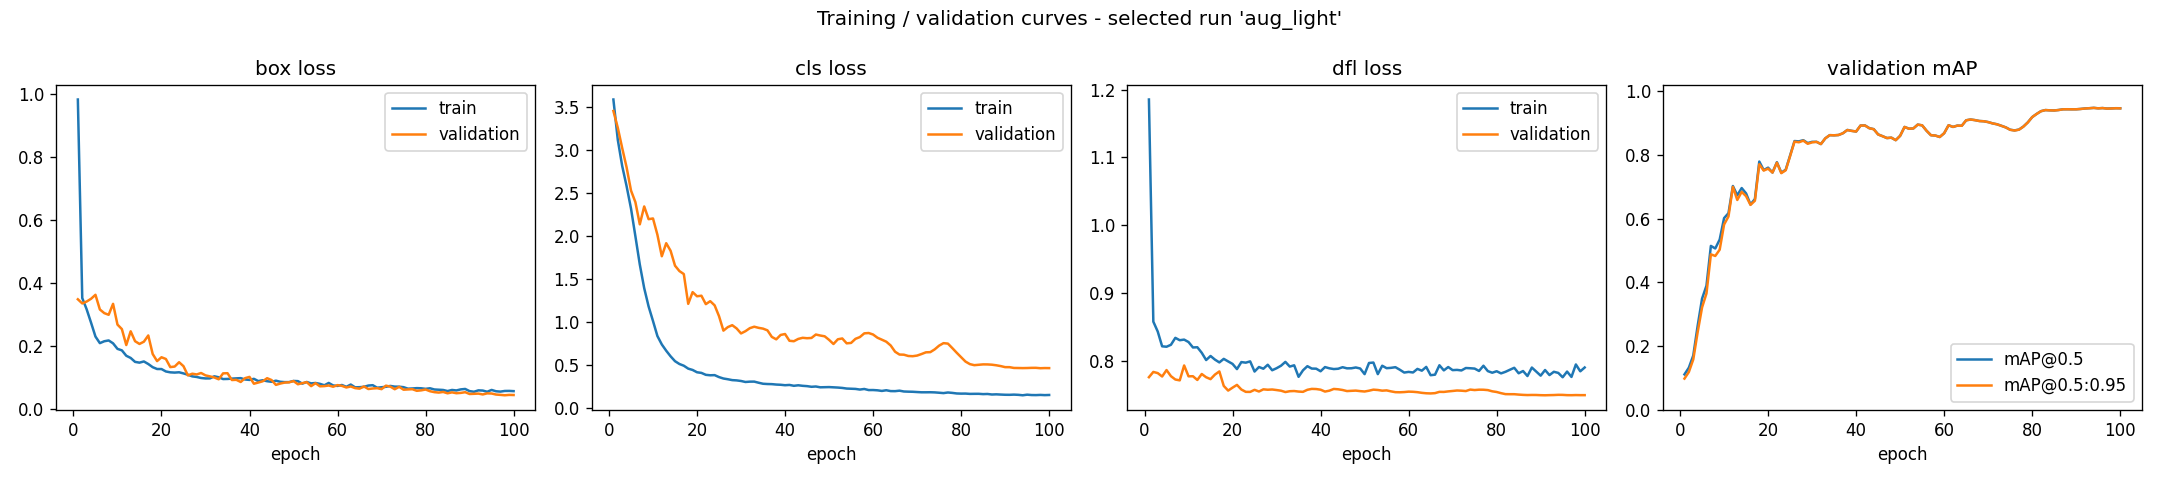

In [9]:
display(Image(str(m3.RESULTS_DIR / "loss_curves.png")))

## 4. Inference-time sweep: confidence and NMS IoU thresholds

These two hyperparameters need no retraining. Confidence is varied with NMS IoU fixed at 0.7, then NMS
IoU is varied with confidence fixed at 0.25. Precision, recall, F1 and mean IoU are computed with the same
matcher as above.

,conf,nms_iou,faces,predictions,correct,wrong_identity,false_positive,missed,precision,recall,f1,face_localization_rate,mean_iou,mean_iou_all_localized
0,0.05,0.7,108,121,84,24,13,0,0.694,0.778,0.734,1.000,0.993,0.991
1,0.10,0.7,108,121,84,24,13,0,0.694,0.778,0.734,1.000,0.993,0.991
2,0.25,0.7,108,116,84,24,8,0,0.724,0.778,0.750,1.000,0.993,0.991
3,0.40,0.7,108,114,84,23,7,1,0.737,0.778,0.757,0.991,0.993,0.991
4,0.50,0.7,108,111,84,23,4,1,0.757,0.778,0.767,0.991,0.993,0.991
5,0.60,0.7,108,100,80,19,1,9,0.800,0.741,0.769,0.917,0.993,0.991
6,0.75,0.7,108,94,77,17,0,14,0.819,0.713,0.762,0.870,0.993,0.992
7,0.90,0.7,108,86,74,12,0,22,0.860,0.685,0.763,0.796,0.993,0.993


,conf,nms_iou,faces,predictions,correct,wrong_identity,false_positive,missed,precision,recall,f1,face_localization_rate,mean_iou,mean_iou_all_localized
0,0.25,0.30,108,116,84,24,8,0,0.724,0.778,0.75,1.0,0.993,0.991
1,0.25,0.45,108,116,84,24,8,0,0.724,0.778,0.75,1.0,0.993,0.991
2,0.25,0.60,108,116,84,24,8,0,0.724,0.778,0.75,1.0,0.993,0.991
3,0.25,0.70,108,116,84,24,8,0,0.724,0.778,0.75,1.0,0.993,0.991
4,0.25,0.80,108,116,84,24,8,0,0.724,0.778,0.75,1.0,0.993,0.991


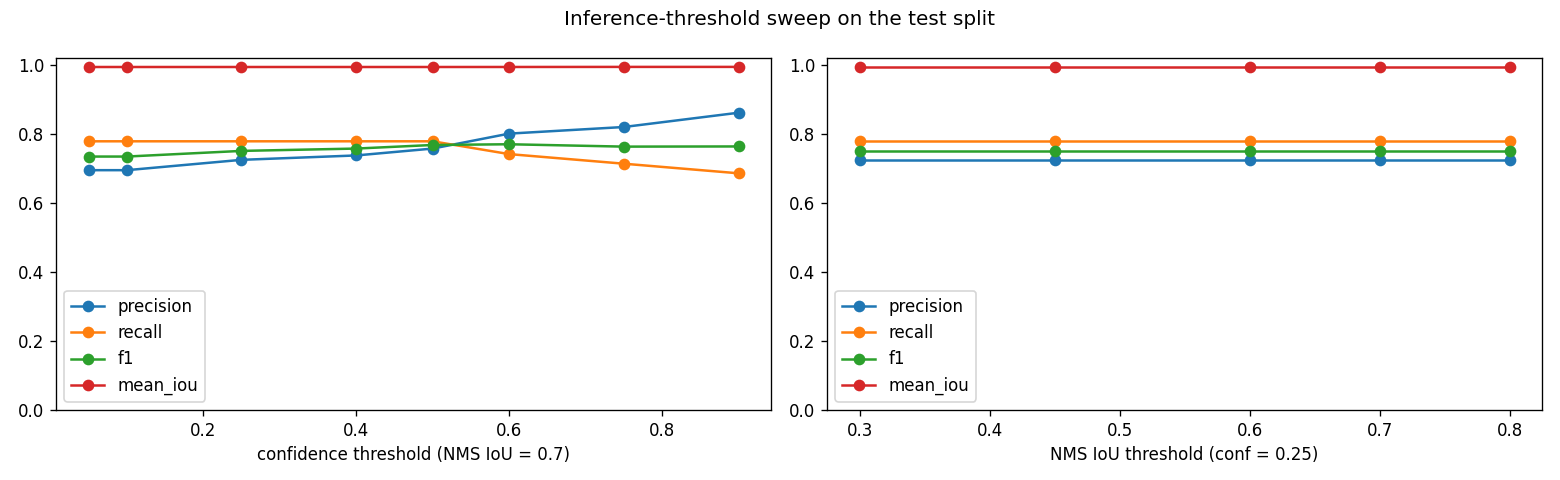

In [10]:
conf_df, nms_df = pipeline.step_threshold_sweep(IMGSZ)
display(conf_df.round(3))
display(nms_df.round(3))
display(Image(str(m3.RESULTS_DIR / "threshold_sweep.png")))

## 5. Detection gallery

Every test image is annotated (12 multi-face grids), plus 7 **stress tests**: exactly
relabelled variants of test frames with smaller faces, low light, blur, or two frames squeezed together.
They surface failure modes the clean test grid cannot show. Colours: green = correct identity,
red = wrong identity, orange = false positive, dashed magenta = missed face. Full captions are in
`results/milestone3/gallery/README.md`.

,file,source,faces,correct,missed,wrong_identity,false_positive
0,01_test_0001.jpg,Test split,9,6,0,3,0
1,02_test_0002.jpg,Test split,9,9,0,0,1
2,03_test_0003.jpg,Test split,9,7,0,2,1
3,04_test_0004.jpg,Test split,9,5,0,4,0
4,05_test_0005.jpg,Test split,9,7,0,2,1
5,06_test_0006.jpg,Test split,9,8,0,1,2
6,07_test_0007.jpg,Test split,9,7,0,2,1
7,08_test_0008.jpg,Test split,9,6,0,3,1
8,09_test_0009.jpg,Test split,9,8,0,1,0
9,10_test_0010.jpg,Test split,9,7,0,2,1


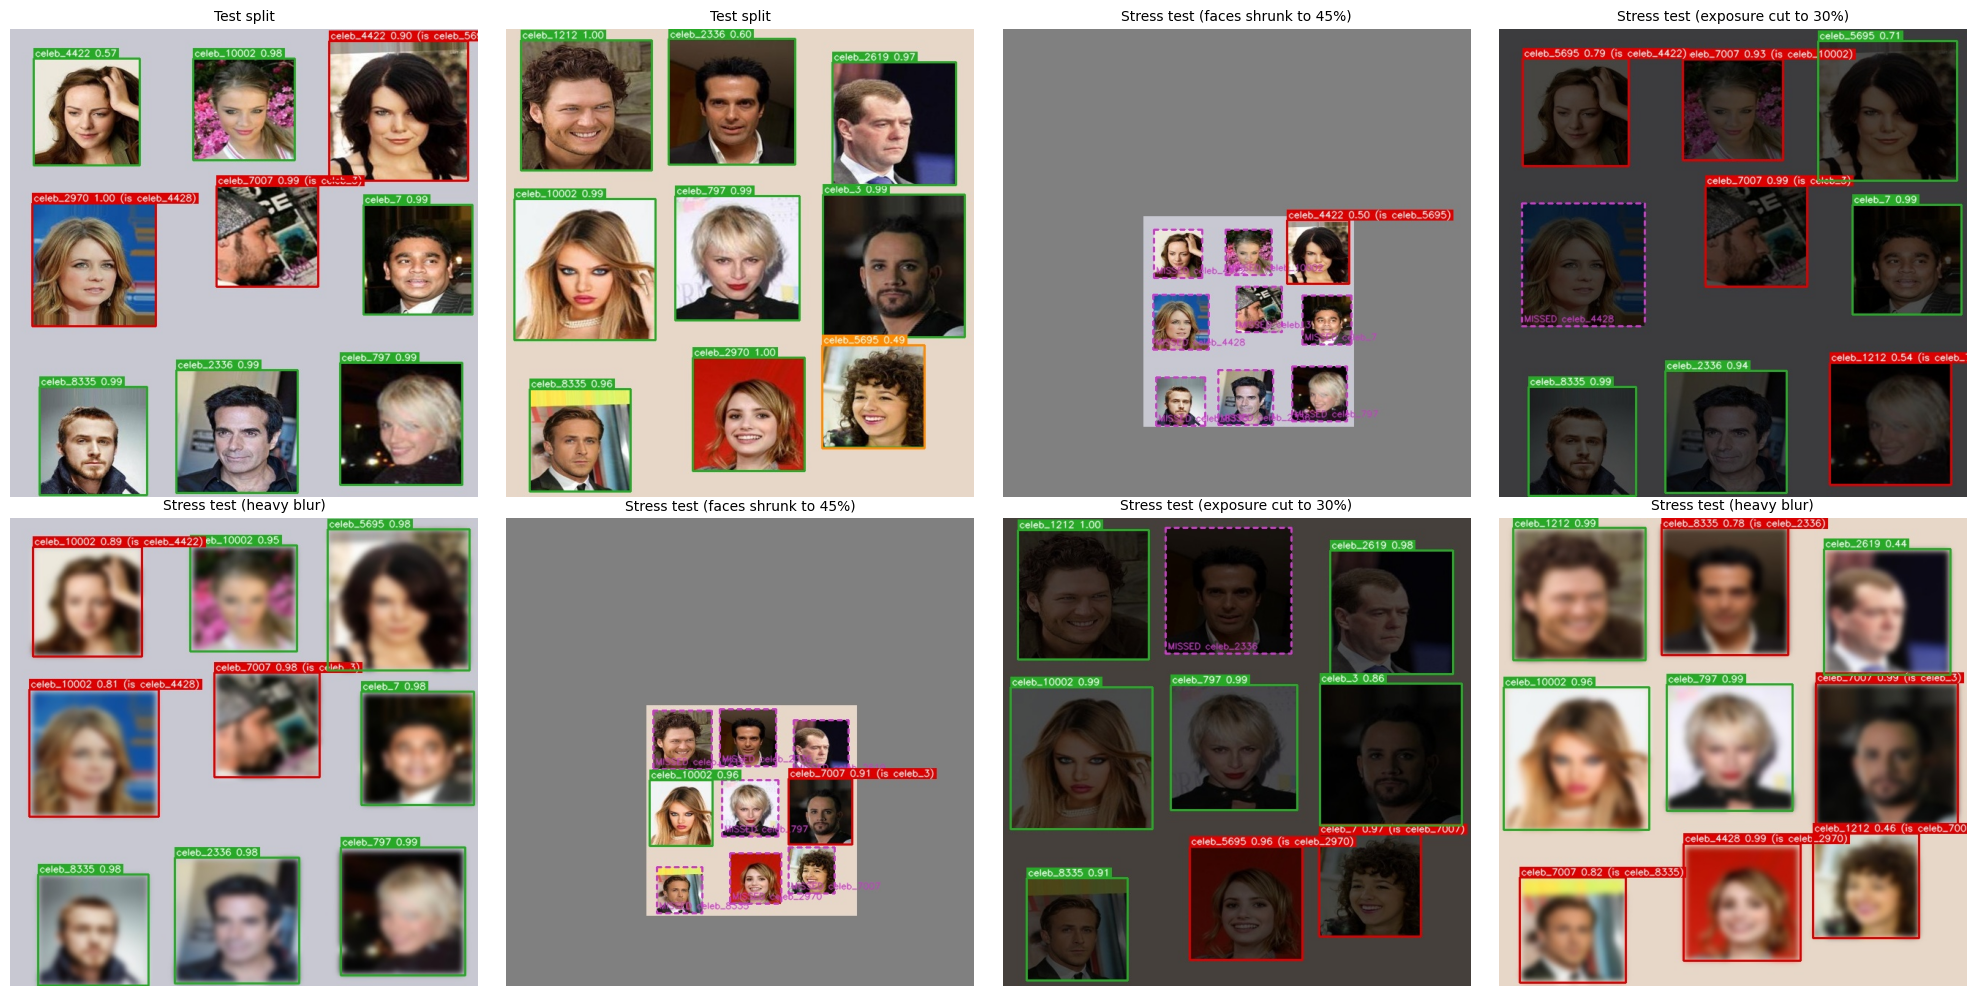

`01_test_0001.jpg` - **Partial.** Test split: 6/9 faces detected with the correct identity; confidence 0.57-0.99; identity confusion: celeb_4428 predicted as celeb_2970; celeb_3 predicted as celeb_7007; celeb_5695 predicted as celeb_4422.

`02_test_0002.jpg` - **Success.** Test split: 9/9 faces detected with the correct identity; confidence 0.60-1.00; 1 extra box(es) on background or duplicate faces.

`03_test_0003.jpg` - **Partial.** Test split: 7/9 faces detected with the correct identity; confidence 0.98-0.99; identity confusion: celeb_2619 predicted as celeb_7007; celeb_4428 predicted as celeb_2970; 1 extra box(es) on background or duplicate faces.

`04_test_0004.jpg` - **Partial.** Test split: 5/9 faces detected with the correct identity; confidence 0.98-1.00; identity confusion: celeb_797 predicted as celeb_10002; celeb_5695 predicted as celeb_4422; celeb_7 predicted as celeb_2619; celeb_3 predicted as celeb_1212.

`05_test_0005.jpg` - **Partial.** Test split: 7/9 faces detected with the correct identity; confidence 0.80-1.00; identity confusion: celeb_2970 predicted as celeb_4428; celeb_4422 predicted as celeb_4428; 1 extra box(es) on background or duplicate faces.

...

`15_test_0001_blur.jpg` - **Partial.** Stress test (heavy blur): 6/9 faces detected with the correct identity; confidence 0.95-0.99; identity confusion: celeb_3 predicted as celeb_7007; celeb_4422 predicted as celeb_10002; celeb_4428 predicted as celeb_10002.

`16_test_0002_small.jpg` - **Failure.** Stress test (faces shrunk to 45%): 1/9 faces detected with the correct identity; confidence 0.96-0.96; missed celeb_2619, celeb_1212, celeb_7007, celeb_2970, celeb_797, celeb_2336, celeb_8335; identity confusion: celeb_3 predicted as celeb_7007.

`17_test_0002_dark.jpg` - **Partial.** Stress test (exposure cut to 30%): 6/9 faces detected with the correct identity; confidence 0.86-1.00; missed celeb_2336; identity confusion: celeb_7007 predicted as celeb_7; celeb_2970 predicted as celeb_5695.

`18_test_0002_blur.jpg` - **Failure.** Stress test (heavy blur): 4/9 faces detected with the correct identity; confidence 0.44-0.99; identity confusion: celeb_3 predicted as celeb_7007; celeb_2970 predicted as celeb_4428; celeb_8335 predicted as celeb_7007; celeb_2336 predicted as celeb_8335; celeb_7007 predicted as celeb_1212.

`19_crowded_two_frames.jpg` - **Failure.** Stress test (two frames squeezed together): 3/18 faces detected with the correct identity; confidence 0.35-0.99; missed celeb_10002, celeb_797, celeb_3, celeb_8335, celeb_7, celeb_7007, celeb_8335; identity confusion: celeb_3 predicted as celeb_7007; celeb_5695 predicted as celeb_4422; celeb_2619 predicted as celeb_4422; celeb_2336 predicted as celeb_4422; celeb_1212 predicted as celeb_4422; celeb_4428 predicted as celeb_2970; celeb_2336 predicted as celeb_4422; celeb_2970 predicted as celeb_4422; 4 extra box(es) on background or duplicate faces.

In [11]:
gallery_df = pipeline.step_gallery(IMGSZ)
display(gallery_df[["file", "source", "faces", "correct", "missed", "wrong_identity", "false_positive"]])

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
picks = list(gallery_df.groupby("source").head(2)["file"])[:8]
picks += [f for f in gallery_df["file"] if f not in picks][:8 - len(picks)]
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for ax, f in zip(axes.flat, picks):
    ax.imshow(mpimg.imread(m3.RESULTS_DIR / "gallery" / f))
    ax.set_title(gallery_df.set_index("file").loc[f, "source"], fontsize=10)
    ax.axis("off")
plt.tight_layout(); plt.show()
for _, row in gallery_df.iterrows():
    display(Markdown(f"`{row['file']}` - {row['caption']}"))

## 6. Live demo

`src/demo_detect.py` loads the fine-tuned model and runs detection on any image.

- Command line: `python src/demo_detect.py --source path/to/image.jpg`
- Web app: `python src/demo_detect.py --app` (add `--share` on Colab for a public link)

Below, the demo runs on a held-out test grid. Set `LAUNCH_APP = True` to start the Gradio upload app.

,identity,confidence,x1,y1,x2,y2
0,celeb_4422,0.897,436,16,626,207
1,celeb_4422,0.571,32,40,177,186
2,celeb_10002,0.978,250,40,389,179
3,celeb_7007,0.987,282,214,421,352
4,celeb_2970,0.997,30,238,199,406
5,celeb_7 (Group 02),0.991,483,240,632,390
6,celeb_797,0.988,451,456,618,623
7,celeb_2336,0.989,227,466,393,634
8,celeb_8335 (Group 02),0.987,40,489,187,637


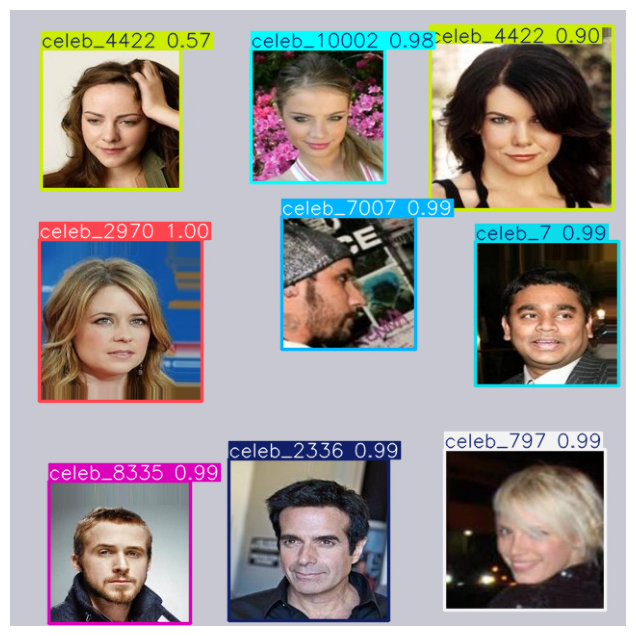

In [12]:
import demo_detect
model = demo_detect.load_model(m3.FINAL_WEIGHTS)
annotated, rows = demo_detect.detect(model, m3.list_images("test")[0], m3.DEFAULT_CONF, m3.DEFAULT_NMS_IOU, IMGSZ)
display(pd.DataFrame(rows, columns=["identity", "confidence", "x1", "y1", "x2", "y2"]))
plt.figure(figsize=(8, 8)); plt.imshow(annotated); plt.axis("off"); plt.show()

LAUNCH_APP = False
if LAUNCH_APP:
    demo_detect.run_app(model, m3.DEFAULT_CONF, m3.DEFAULT_NMS_IOU, share=IN_COLAB)

## 7. Results document and outputs

Writes `docs/milestone3_detection_results.md` (metrics table, sweep summary, loss curves, interpretation
draft) and zips every generated file. On Colab the zip downloads automatically: unzip it into your local
copy of the repo, review the interpretation paragraphs, then commit and push. Also save this executed
notebook (*File -> Download -> .ipynb*) over `notebooks/06_yolov8_training_evaluation.ipynb` so the
committed version shows its outputs.

In [13]:
doc = pipeline.step_write_doc(report, sweep_df, conf_df, nms_df, gallery_df, EPOCHS, m2_ref)
display(Markdown(doc.read_text()))

import zipfile
ZIP = ROOT / "milestone3_outputs.zip"
with zipfile.ZipFile(ZIP, "w", zipfile.ZIP_DEFLATED) as z:
    for p in [ROOT / "detection_dataset" / "data.yaml", m3.FINAL_WEIGHTS, doc,
              *sorted(p for p in m3.SCALED_DATASET_DIR.rglob("*") if p.is_file() and p.suffix != ".cache"),
              *sorted(p for p in m3.RESULTS_DIR.rglob("*") if p.is_file())]:
        z.write(p, p.relative_to(ROOT))
print(f"Packed {ZIP} ({ZIP.stat().st_size / 1e6:.1f} MB)")
if IN_COLAB:
    from google.colab import files
    files.download(str(ZIP))

# Project 1 - Milestone 3: YOLOv8 Transfer Learning and Evaluation

IE7615 - Group 02

## 1. Setup

We fine-tuned COCO-pretrained YOLOv8 models (Ultralytics) to find every face in a synthetic 3x3 grid of
CelebA face crops and name it as one of the 13 class-pool identities (one YOLO class per identity).

**Data.** A first run on our submitted Milestone 2 dataset (6 base grids, 30 images) learned where faces
are but not who they are: each identity appeared in only about 4 of its ~25 photos, and the test split
missed 4 identities. We rebuilt the dataset with the **same Milestone 2 method** (same identities and class
ids, 640 px 3x3 grids, same scale/placement jitter; `src/build_m3_scaled_dataset.py`), changing only its
size and split: each identity's photos are divided 70/15/15 into train/val/test **before** any grid is
built, so no photo appears in two splits, and every identity appears in every split. The result has
120 train, 12 val and 12 test grids (108 test faces), about
17 distinct training photos per identity.

**Training.** AdamW (fixed so the learning rate setting is honoured), up to 100 epochs with early
stopping (patience 30), batch 16, seed 42. 6 configurations were trained (section 3) and the
final model was **selected on validation mAP@0.5:0.95 only**; the test split was used once for reporting.
Selected run: **`aug_light`** (lighter online augmentation (no mosaic, gentler jitter); `models/celeba_yolov8_best.pt`).

## 2. Test-set results

| Metric | Value |
|---|---|
| mAP@0.5 | 0.879 |
| mAP@0.5:0.95 | 0.876 |
| Precision | 0.849 |
| Recall | 0.759 |
| Mean IoU (correct detections) | 0.993 |
| Faces located (any identity) | 108 / 108 |
| Faces correctly identified | 84 / 108 |

mAP, precision and recall are Ultralytics' validator metrics. IoU comes from our matcher at confidence
0.25 and NMS IoU 0.7: each prediction claims the unclaimed ground-truth face it overlaps
most (IoU >= 0.5), and IoU is averaged over correctly identified faces. Per-identity results are in
Appendix A.

**Effect of the dataset** (each row tested on its own dataset's held-out split):

| model / data | test mAP50 | test mAP50-95 | precision | recall |
|---|---|---|---|---|
| baseline, Milestone 2 data (20/5/5 images) | 0.232 | 0.150 | 0.452 | 0.400 |
| baseline, scaled data (120/12/12 grids) | 0.799 | 0.789 | 0.648 | 0.824 |
| aug_light (selected), scaled data | 0.879 | 0.876 | 0.849 | 0.759 |

## 3. Hyperparameter sweep

Training-time settings (one change at a time from the baseline; augmentation details in Appendix B):

| run | model | lr0 | imgsz | epochs_run | val mAP50 | val mAP50-95 | test mAP50 | test mAP50-95 |
|---|---|---|---|---|---|---|---|---|
| baseline | yolov8n | 0.001 | 640 | 62 | 0.897 | 0.896 | 0.799 | 0.789 |
| lr_low | yolov8n | 0.0002 | 640 | 81 | 0.864 | 0.863 | 0.861 | 0.855 |
| lr_high | yolov8n | 0.005 | 640 | 100 | 0.737 | 0.737 | 0.687 | 0.682 |
| imgsz_416 | yolov8n | 0.001 | 416 | 100 | 0.835 | 0.835 | 0.847 | 0.842 |
| aug_light | yolov8n | 0.001 | 640 | 100 | 0.947 | 0.947 | 0.879 | 0.876 |
| yolov8s_aug_light | yolov8s | 0.001 | 640 | 100 | 0.933 | 0.933 | 0.936 | 0.932 |

![Validation curves across sweep runs](../results/milestone3/training_sweep_curves.png)

Inference-time settings (confidence threshold and NMS IoU threshold, test split; tables in Appendix C):

![Threshold sweep](../results/milestone3/threshold_sweep.png)

## 4. Training and validation curves (selected run)

![Loss curves](../results/milestone3/loss_curves.png)

## 5. Interpretation

**Localization is solved; identification is the bottleneck.** The detector places a box on
100% of test faces, and those boxes are almost exact (mean IoU
0.993). That is why mAP@0.5 and mAP@0.5:0.95 are almost identical: nearly every correct detection also passes the strictest IoU threshold. This is partly a property of our synthetic grids, where each face is a sharp-edged square crop on a plain background; real group photos would be harder to localize. The remaining errors are mostly identity errors: 24
faces were found but given the wrong name, against 0 missed faces and 8
false positive(s). The curves show the same pattern: box loss converges for training and validation alike,
while validation classification loss levels off at 0.47 against 0.16 for
training, a sign of overfitting to about 17 photos per identity. Accuracy varies by identity,
from mAP@0.5 = 0.641 (celeb_4428) up to 0.995; Group 02's
identities score celeb_3 0.995, celeb_7 0.995, celeb_1212 0.995, celeb_8335 0.954.

**Data mattered most.** With the same baseline configuration, the original 30-image Milestone 2 dataset
reaches test mAP@0.5 = 0.232, while the scaled dataset reaches
0.799. Because test photos never appear in
training, these scores measure recognizing known celebrities in new photos, which is what the final system
must do.

**Hyperparameters.** A 5x higher learning rate reached val mAP@0.5 = 0.737 (baseline 0.897). A 5x lower rate (0.0002) learned more slowly (val mAP@0.5 = 0.864). Shrinking the input to 416 px gave val mAP@0.5 = 0.835, since faces become smaller. Lighter online augmentation reached val mAP@0.5:0.95 = 0.947 vs 0.896 for the baseline, consistent with the grids already being varied by construction. The larger YOLOv8s model did not clearly improve on the same settings (val mAP@0.5:0.95 0.933 vs 0.947 for YOLOv8n), suggesting the bottleneck is the number of distinct photos rather than model size. On the test split `yolov8s_aug_light` scored slightly higher than the selected `aug_light`; with only 12 test grids, differences this small are within noise, so we keep the validation choice. At inference, raising the confidence threshold trades recall for
precision (0.694/0.778 at
0.05 to 0.860/0.685
at 0.90), with the best F1 at 0.60.
The NMS IoU threshold had no effect, because faces in a grid never overlap.

**Limits and next steps.** Of the 12 test grids, 4 are
near-perfect (at least 8 of 9 faces correct), 8 partial and
0 failures. Stress tests show where the model breaks (faces shrunk to 45%: 1/18 faces correct; two frames squeezed together: 3/18 faces correct; exposure cut to 30%: 10/18 faces correct; heavy blur: 10/18 faces correct):
training faces always fill 65-92% of a grid cell, so much smaller faces are outside what it learned. For
Milestone 4 we plan to add smaller-scale and crowded compositions to training and to compare this
single-stage detector with a two-stage pipeline (face detection followed by the Milestone 1 classifier),
which targets the identity errors directly.

## 6. Gallery and demo

- Gallery: `results/milestone3/gallery/README.md` (19 annotated multi-face images graded
  success / partial / failure, with captions).
- Live demo: `python src/demo_detect.py --app` (upload app) or `python src/demo_detect.py --source <image>`;
  instructions in the README.

---

## Appendix A. Per-identity test results

"(ours)" marks Group 02's identities.

| class | identity | test faces | precision | recall | mAP50 | mAP50-95 | mean IoU |
|---|---|---|---|---|---|---|---|
| 0 | celeb_3 (ours) | 8 | 1 | 0.543 | 0.995 | 0.995 | 0.994 |
| 1 | celeb_7 (ours) | 8 | 0.991 | 1 | 0.995 | 0.995 | 0.994 |
| 2 | celeb_797 | 8 | 0.968 | 0.750 | 0.927 | 0.927 | 0.992 |
| 3 | celeb_1212 (ours) | 9 | 0.892 | 1 | 0.995 | 0.995 | 0.994 |
| 4 | celeb_2336 | 8 | 1 | 0.933 | 0.995 | 0.995 | 0.994 |
| 5 | celeb_2619 | 9 | 0.925 | 0.444 | 0.802 | 0.787 | 0.991 |
| 6 | celeb_2970 | 8 | 0.704 | 0.750 | 0.792 | 0.792 | 0.990 |
| 7 | celeb_4422 | 9 | 0.631 | 0.556 | 0.788 | 0.788 | 0.989 |
| 8 | celeb_4428 | 8 | 0.727 | 0.375 | 0.641 | 0.638 | 0.994 |
| 9 | celeb_5695 | 8 | 0.817 | 0.625 | 0.683 | 0.666 | 0.993 |
| 10 | celeb_7007 | 9 | 0.722 | 0.889 | 0.931 | 0.931 | 0.994 |
| 11 | celeb_8335 (ours) | 8 | 0.871 | 1 | 0.954 | 0.954 | 0.993 |
| 12 | celeb_10002 | 8 | 0.787 | 1 | 0.928 | 0.928 | 0.994 |

## Appendix B. Sweep configurations

| run | augmentation | what changes |
|---|---|---|
| baseline | Ultralytics defaults | Reference: AdamW lr0=0.001, 640 px, default online augmentation |
| lr_low | Ultralytics defaults | Learning rate 5x lower |
| lr_high | Ultralytics defaults | Learning rate 5x higher |
| imgsz_416 | Ultralytics defaults | Smaller input resolution (faster, smaller faces) |
| aug_light | mosaic=0.0, scale=0.2, translate=0.05, hsv_h=0.005, hsv_s=0.3, hsv_v=0.2 | Lighter online augmentation (no mosaic, gentler jitter) |
| yolov8s_aug_light | mosaic=0.0, scale=0.2, translate=0.05, hsv_h=0.005, hsv_s=0.3, hsv_v=0.2 | Larger model (YOLOv8s, ~3x parameters) with lighter augmentation |

## Appendix C. Inference-threshold tables (test split)

| conf | predictions | correct | wrong_identity | false_positive | missed | precision | recall | f1 |
|---|---|---|---|---|---|---|---|---|
| 0.050 | 121 | 84 | 24 | 13 | 0 | 0.694 | 0.778 | 0.734 |
| 0.100 | 121 | 84 | 24 | 13 | 0 | 0.694 | 0.778 | 0.734 |
| 0.250 | 116 | 84 | 24 | 8 | 0 | 0.724 | 0.778 | 0.750 |
| 0.400 | 114 | 84 | 23 | 7 | 1 | 0.737 | 0.778 | 0.757 |
| 0.500 | 111 | 84 | 23 | 4 | 1 | 0.757 | 0.778 | 0.767 |
| 0.600 | 100 | 80 | 19 | 1 | 9 | 0.800 | 0.741 | 0.769 |
| 0.750 | 94 | 77 | 17 | 0 | 14 | 0.819 | 0.713 | 0.762 |
| 0.900 | 86 | 74 | 12 | 0 | 22 | 0.860 | 0.685 | 0.763 |

| nms_iou | predictions | correct | false_positive | precision | recall | f1 |
|---|---|---|---|---|---|---|
| 0.300 | 116 | 84 | 8 | 0.724 | 0.778 | 0.750 |
| 0.450 | 116 | 84 | 8 | 0.724 | 0.778 | 0.750 |
| 0.600 | 116 | 84 | 8 | 0.724 | 0.778 | 0.750 |
| 0.700 | 116 | 84 | 8 | 0.724 | 0.778 | 0.750 |
| 0.800 | 116 | 84 | 8 | 0.724 | 0.778 | 0.750 |

Per-run logs (`results.csv`, `args.yaml`, Ultralytics plots) are in `results/milestone3/train_logs/`.


Packed /content/ie7615-group-02-project1/milestone3_outputs.zip (29.2 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>